# Eksperimen Pengaruh Inisialisasi Bobot

Notebook ini ditujukan untuk menguji pengaruh berbagai metode inisialisasi bobot (Uniform, Normal, Xavier, Kaiming) terhadap kecepatan konvergensi, loss, dan distribusi bobot.

In [179]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
import ffnn

In [180]:
SEED=34

In [181]:
df = pd.read_csv("../data/dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [182]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [183]:
df.shape

(10000, 12)

# Data Preprocessing

we will label encode college_tier and university_ranking_band since they have an order

In [184]:
college_tier_map = {"Tier 3":0, "Tier 2":1, "Tier 1":2}
df["college_tier"] = df["college_tier"].map(college_tier_map)
df["college_tier"].value_counts()

college_tier
1    3993
2    3034
0    2973
Name: count, dtype: int64

In [185]:
ranking_map = {"300+":0,"100-300":1,"Top 100":2}
df["university_ranking_band"] = df["university_ranking_band"].map(ranking_map)
df["university_ranking_band"].value_counts()

university_ranking_band
0    4075
1    3975
2    1950
Name: count, dtype: int64

Target encoding for placement_status

In [186]:
target_map = {"Placed":1,"Not Placed":0}
df["placement_status"]=df["placement_status"].map(target_map)
df["placement_status"].value_counts()

placement_status
1    6153
0    3847
Name: count, dtype: int64

In [187]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,1,Canada,1,2,53.574150,64.177062,Data Science,Consulting,5.481450,1
1,6.889389,0,0,UK,0,1,60.687750,88.346052,Data Science,Consulting,4.625099,1
2,7.518151,0,2,UK,1,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,1
3,8.218424,0,1,UK,1,3,73.461500,78.204854,AI/ML,Tech,5.150674,1
4,6.812677,1,1,USA,1,4,86.518121,44.680881,Data Science,Consulting,3.888824,1


In [188]:
categorical_col = df.select_dtypes(include=["object"]).columns
print(categorical_col)

Index(['country', 'specialization', 'industry'], dtype='object')


In [189]:
num_cols = df.select_dtypes(exclude=["object"]).columns
print(num_cols)

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score', 'placement_status'],
      dtype='object')


### Preprocessing Pipeline

In [190]:
transformed_df = df.copy()

In [191]:
ss = StandardScaler()
ss.set_output(transform="pandas")

transformed_num_cols = transformed_df.select_dtypes(exclude="object").columns.drop("placement_status")
print(transformed_num_cols)

transformed_num_df = ss.fit_transform(transformed_df[transformed_num_cols])
transformed_num_df.head()

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score'],
      dtype='object')


,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116


In [192]:
oh_cols = ["country","specialization","industry"]

In [193]:
onehot = OneHotEncoder(sparse_output=False)

one_hot_encoded = onehot.fit_transform(transformed_df[oh_cols])


one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=onehot.get_feature_names_out(oh_cols))

transformed_encoded_df = pd.concat([transformed_num_df, one_hot_df], axis=1)

transformed_encoded_df.head()

,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score,country_Canada,country_Germany,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Consulting,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


# Modelling Experiment

In [194]:
X = transformed_encoded_df
y = transformed_df["placement_status"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=SEED)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 24), (2000, 24), (8000,), (2000,))

### Control Model

The model's performance is compared with other model variation

In [195]:
control_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

## 1. Definisi Model dan Inisialisasi

Kita akan menggunakan arsitektur base: M x 16 x 2. Layer Hidden menggunakan ReLU, dan Output menggunakan Softmax.
Kita bandingkan 5 metode inisialisasi: Zero, Uniform, Normal, Xavier Uniform (Default), dan Kaiming Uniform.

In [196]:
def create_model(init_type):
    # Base architecture: Input(X_train.shape[1]) -> 16 (ReLU) -> 2 (Softmax)
    l1 = ffnn.Linear(X_train.shape[1], 16)
    l2 = ffnn.Linear(16, 2)
    
    if init_type == "uniform":
        ffnn.init.uniform(l1.weights, -0.5, 0.5, seed=SEED)
        ffnn.init.uniform(l2.weights, -0.5, 0.5, seed=SEED)
    elif init_type == "zero":
        ffnn.init.zeros(l1.weights)
        ffnn.init.zeros(l2.weights)
    elif init_type == "normal":
        ffnn.init.normal(l1.weights, 0, 0.1, seed=SEED)
        ffnn.init.normal(l2.weights, 0, 0.1, seed=SEED)
    elif init_type == "kaiming":
        ffnn.init.kaiming_uniform(l1.weights)
        ffnn.init.kaiming_uniform(l2.weights)
    elif init_type == "xavier":
        ffnn.init.xavier_uniform(l1.weights)
        ffnn.init.xavier_uniform(l2.weights)
        
    model = ffnn.Model([l1, ffnn.Relu(), l2, ffnn.Softmax()], loss=ffnn.CrossEntropyLoss())
    return model, l1, l2

## 2. Eksperimen: Melatih Model dengan Berbagai Inisialisasi

In [197]:
EPOCHS = 20
LR = 0.05
BATCH_SIZE = 32

print("Training Model - Zero Init")
model_zero, l1_zero, l2_zero = create_model("zero")
opt_zero = ffnn.SGD(lr=LR)
hist_zero = model_zero.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, optimizer=opt_zero, validation_data=(X_test, y_test), seed=SEED)

print("\nTraining Model - Uniform Init")
model_uni, l1_uni, l2_uni = create_model("uniform")
opt_uni = ffnn.SGD(lr=LR)
hist_uni = model_uni.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, optimizer=opt_uni, validation_data=(X_test, y_test), seed=SEED)

print("\nTraining Model - Normal Init")
model_norm, l1_norm, l2_norm = create_model("normal")
opt_norm = ffnn.SGD(lr=LR)
hist_norm = model_norm.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, optimizer=opt_norm, validation_data=(X_test, y_test), seed=SEED)

print("\nTraining Model - Xavier/Glorot Init")
model_xav, l1_xav, l2_xav = create_model("xavier")
opt_xav = ffnn.SGD(lr=LR)
hist_xav = model_xav.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, optimizer=opt_xav, validation_data=(X_test, y_test), seed=SEED)

print("\nTraining Model - Kaiming/He Init")
model_kai, l1_kaim, l2_kai = create_model("kaiming")
opt_kai = ffnn.SGD(lr=LR)
hist_kai = model_kai.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, optimizer=opt_kai, validation_data=(X_test, y_test), seed=SEED)

Training Model - Zero Init
Epoch 1/20 [==============================] - train_loss: 0.666429 - val_loss: 0.666319
Epoch 2/20 [==============================] - train_loss: 0.666364 - val_loss: 0.666250
Epoch 3/20 [==============================] - train_loss: 0.666398 - val_loss: 0.666286
Epoch 4/20 [==============================] - train_loss: 0.666728 - val_loss: 0.666625
Epoch 5/20 [==============================] - train_loss: 0.666344 - val_loss: 0.666226
Epoch 6/20 [==============================] - train_loss: 0.666349 - val_loss: 0.666229
Epoch 7/20 [==============================] - train_loss: 0.666344 - val_loss: 0.666227
Epoch 8/20 [==============================] - train_loss: 0.666385 - val_loss: 0.666273
Epoch 9/20 [==============================] - train_loss: 0.666354 - val_loss: 0.666234
Epoch 10/20 [==============================] - train_loss: 0.666359 - val_loss: 0.666238
Epoch 11/20 [==============================] - train_loss: 0.666492 - val_loss: 0.666383
Epo

## 3. Perbandingan Hasil Prediksi

In [198]:
from sklearn.metrics import accuracy_score, f1_score

models = [
    ("Zero", model_zero),
    ("Uniform", model_uni),
    ("Normal", model_norm),
    ("Xavier", model_xav),
    ("Kaiming", model_kai)
]

print("Perbandingan Akurasi & F1 (Test Data):\n")
for name, m in models:
    preds = m.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"{name:<10} : acc={acc:.4f} | f1={f1:.4f}")

Perbandingan Akurasi & F1 (Test Data):



Zero       : acc=0.6155 | f1=0.7620
Uniform    : acc=0.7510 | f1=0.8029
Normal     : acc=0.7575 | f1=0.8076
Xavier     : acc=0.7510 | f1=0.8019
Kaiming    : acc=0.7460 | f1=0.7971


## 4. Grafik Training & Validation Loss

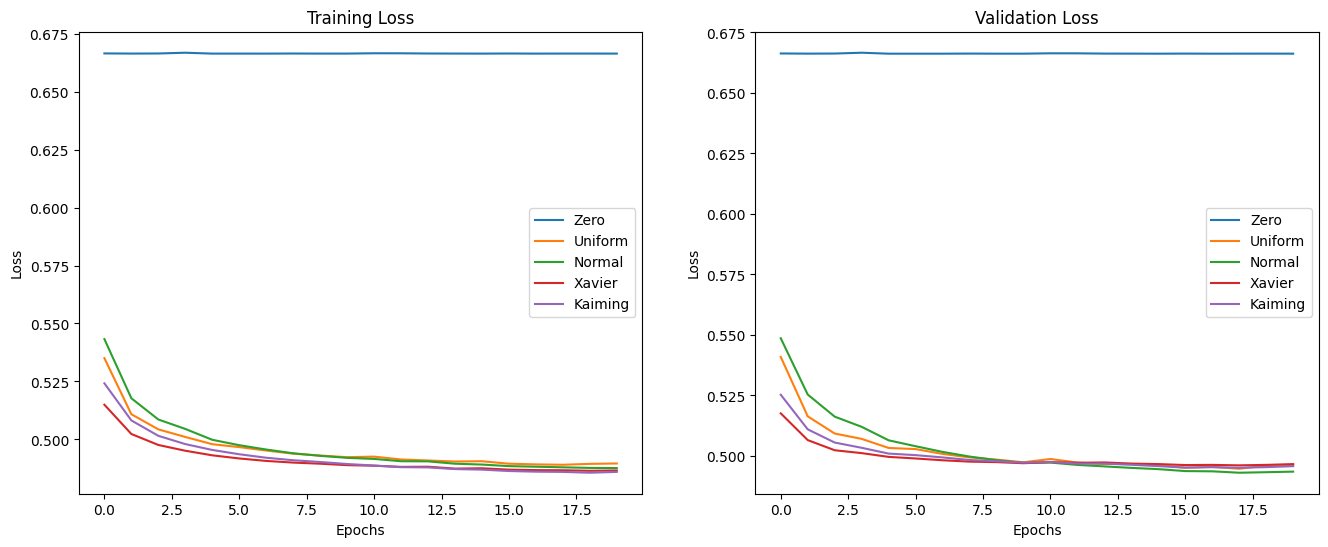

In [199]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(hist_zero["train_loss"], label="Zero")
axes[0].plot(hist_uni["train_loss"], label="Uniform")
axes[0].plot(hist_norm["train_loss"], label="Normal")
axes[0].plot(hist_xav["train_loss"], label="Xavier")
axes[0].plot(hist_kai["train_loss"], label="Kaiming")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(hist_zero["val_loss"], label="Zero")
axes[1].plot(hist_uni["val_loss"], label="Uniform")
axes[1].plot(hist_norm["val_loss"], label="Normal")
axes[1].plot(hist_xav["val_loss"], label="Xavier")
axes[1].plot(hist_kai["val_loss"], label="Kaiming")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.show()

## 5. Distribusi Bobot dan Gradien\n

Distribusi Bobot (Layer 0 & Layer 2):

Zero:


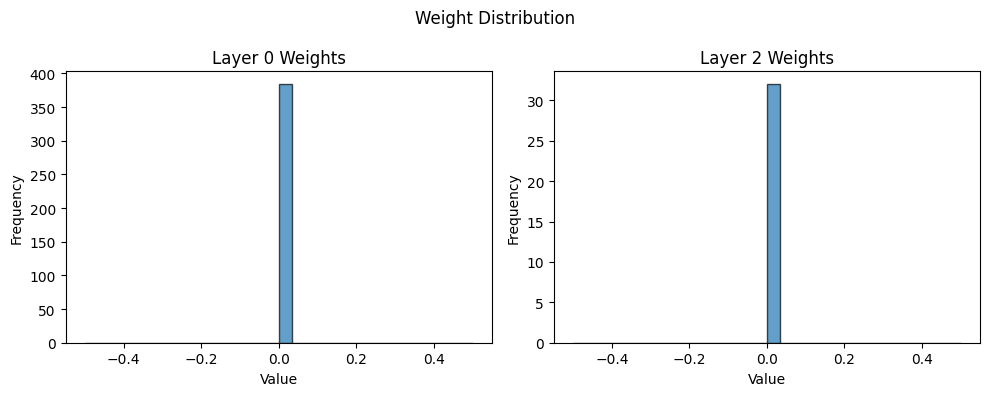


Uniform:


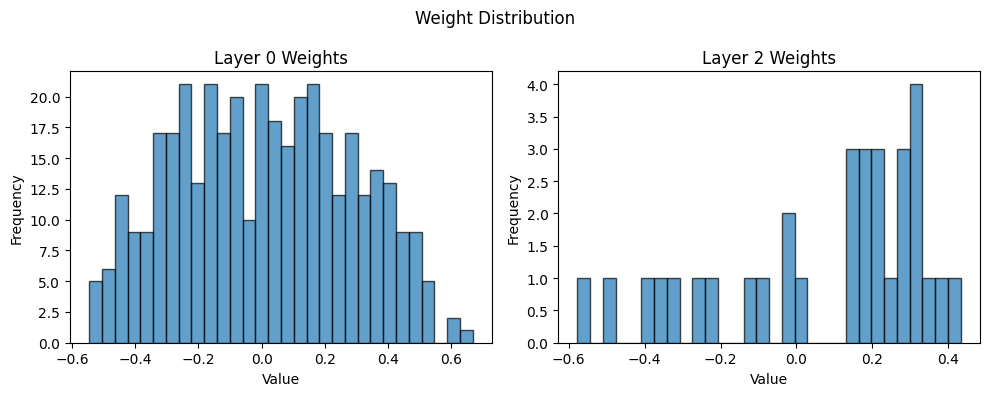


Normal:


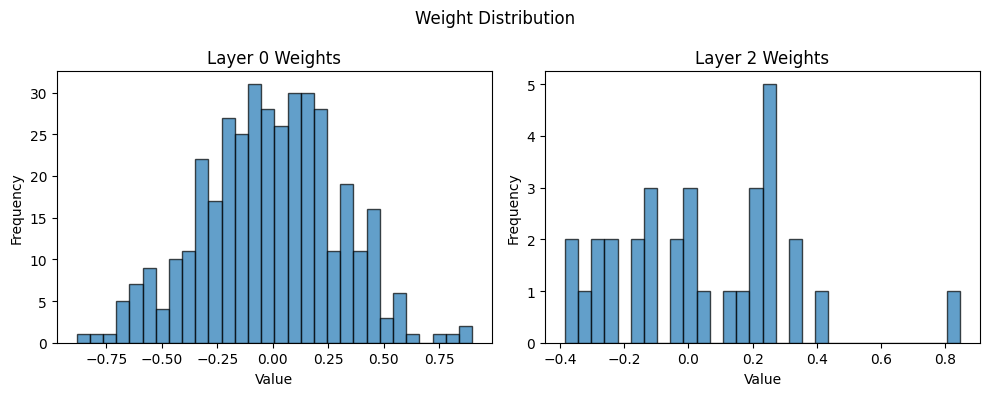


Xavier:


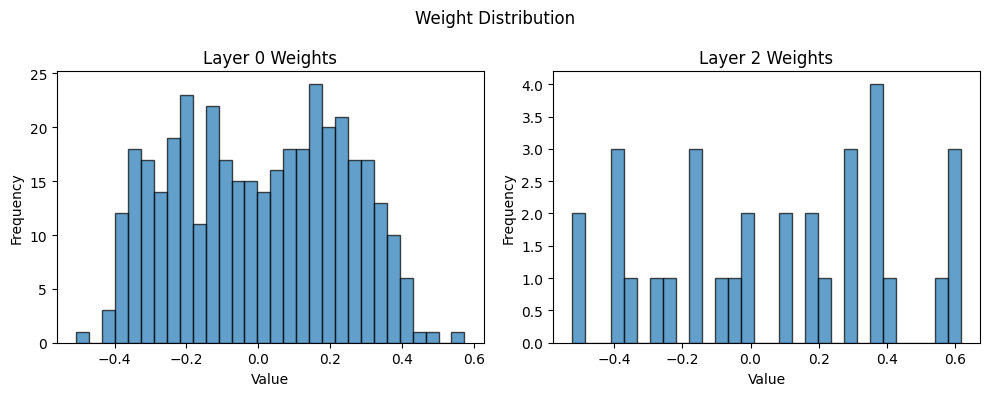


Kaiming:


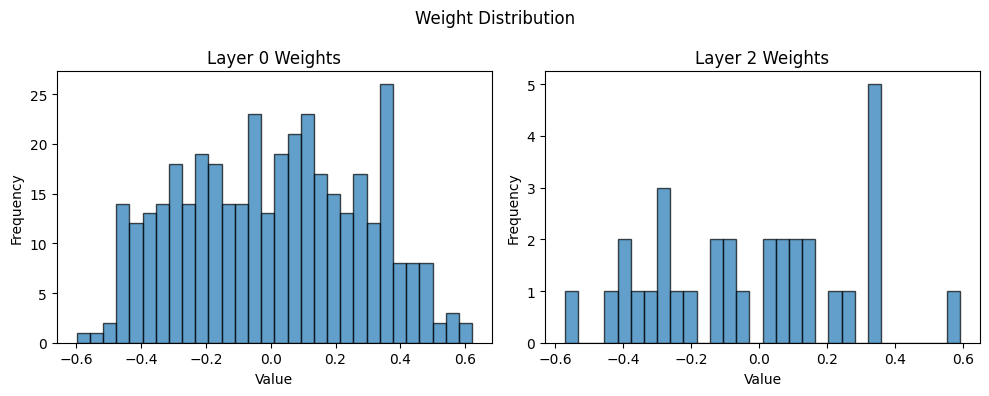

In [200]:
# Akan ditampilkan distribusi bobot dari layer 0 dan layer 2
print("Distribusi Bobot (Layer 0 & Layer 2):")
print("\nZero:")
model_zero.plot_weights([0, 2])
print("\nUniform:")
model_uni.plot_weights([0, 2])
print("\nNormal:")
model_norm.plot_weights([0, 2])
print("\nXavier:")
model_xav.plot_weights([0, 2])
print("\nKaiming:")
model_kai.plot_weights([0, 2])

Distribusi Gradien (Layer 0 & Layer 2):

Zero:


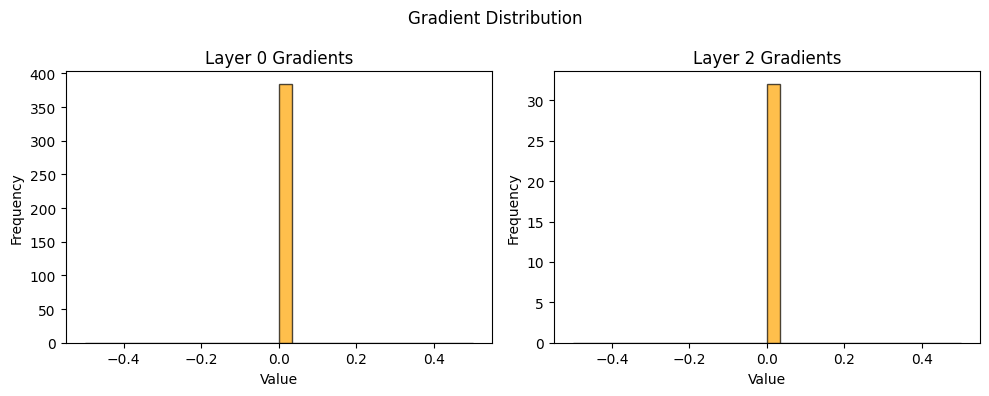


Uniform:


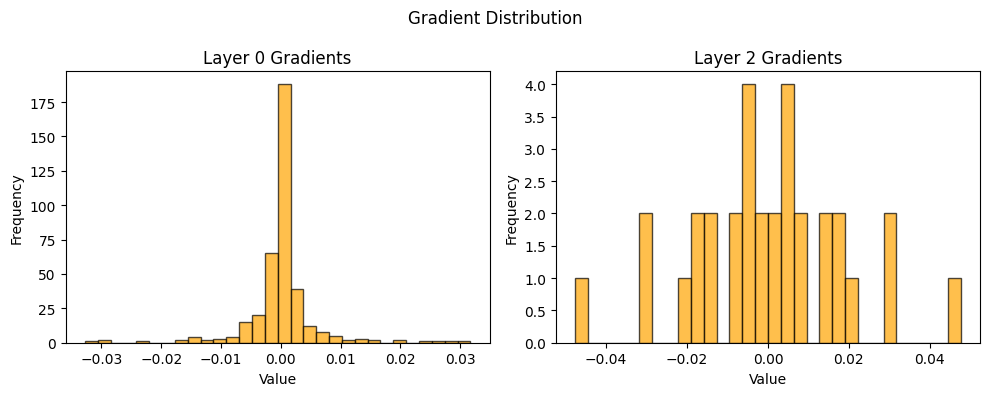


Normal:


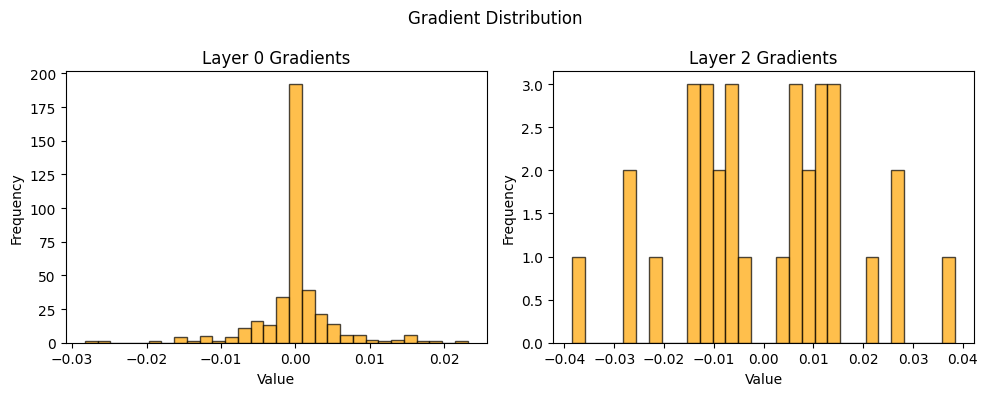


Xavier:


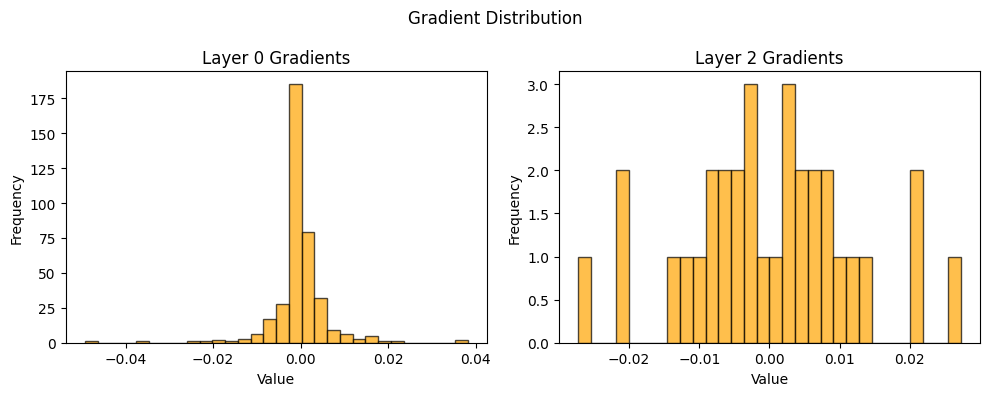


Kaiming:


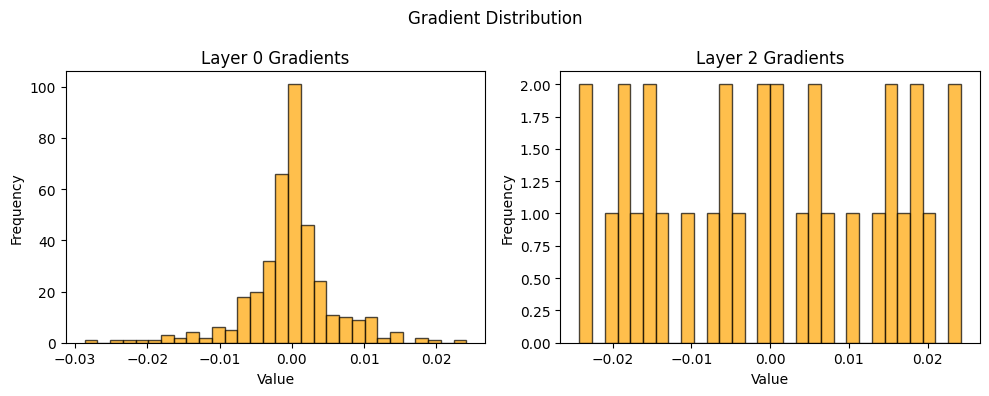

In [201]:
print("Distribusi Gradien (Layer 0 & Layer 2):")
print("\nZero:")
model_zero.plot_gradients([0, 2])
print("\nUniform:")
model_uni.plot_gradients([0, 2])
print("\nNormal:")
model_norm.plot_gradients([0, 2])
print("\nXavier:")
model_xav.plot_gradients([0, 2])
print("\nKaiming:")
model_kai.plot_gradients([0, 2])